# Notebook 2 - Weighted Layer Aggregation + CBM - HuBERT backbone

Pipeline :
1. Per-layer probing with selection on **validation**
2. Weighted aggregation - training shared in `xai_common`
3. Binarization **per gender, train-only thresholds**
4. CBM on three concept levels + **hard** variant
5. Black-box baseline: MLP on the weighted embedding and on the 12 concatenated layers
6. **WA/UA/macro-F1** metrics + McNemar/bootstrap
7. Interventions (random and uncertainty-based) on the acoustic set only
8. **Temporal attention** over the chunks and **CEM**

Split: train = Session 1–4, test = Session 5; internal validation = Session 4

## 1 · Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scikit-learn matplotlib seaborn scipy -q

In [ ]:
import sys, json
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

PROJ = Path('/content/drive/MyDrive/Colab Notebooks/XAI_SER/code')
sys.path.append(str(PROJ))
import xai_common as xc

BACKBONE = 'hubert'
PATHS = xc.get_paths(BACKBONE, PROJ)
DATA_DIR, MODEL_DIR, RESULTS_DIR = PATHS['data'], PATHS['model'], PATHS['results']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
xc.set_seed()
print(f'Backbone: {BACKBONE}   Device: {DEVICE}')

Backbone: hubert   Device: cuda


## 2 · Load datas

In [ ]:
emb_data = np.load(DATA_DIR / 'layer_embeddings.npz')
chk_data = np.load(DATA_DIR / 'chunk_embeddings.npz')
valid_ids     = json.load(open(DATA_DIR / 'valid_ids.json'))
metadata      = json.load(open(DATA_DIR / 'metadata.json'))
concept_names = json.load(open(DATA_DIR / 'concept_names.json'))

X_layers = np.stack([emb_data[u] for u in valid_ids])                        # (N, 12, 768)
X_chunks = np.stack([chk_data[u] for u in valid_ids]).astype(np.float32)     # (N, 8, 768)
X_concepts_raw = np.load(DATA_DIR / 'X_concepts.npy')                        # (N, 16) with NaN
y_emotion = np.load(DATA_DIR / 'y_emotion.npy')
sessions = np.array([metadata[u]['session'] for u in valid_ids])
genders  = np.array([metadata[u]['gender'] for u in valid_ids])

train_mask = sessions != '5'
test_mask  = ~train_mask
val_mask   = sessions == '4'                     # internal validation
inner_val  = val_mask[train_mask]

X_concepts = xc.impute_nan(X_concepts_raw, train_mask)   # median imputation

X_lay_tr, X_lay_te = X_layers[train_mask], X_layers[test_mask]
y_tr, y_te = y_emotion[train_mask], y_emotion[test_mask]
print(f'Train: {train_mask.sum()}   Test: {test_mask.sum()}   (internal validation: {val_mask.sum()})')
print(f'Concepts ({len(concept_names)}): {concept_names}')
print(f'y train: {dict(Counter(y_tr.tolist()))}   y test: {dict(Counter(y_te.tolist()))}')

Train: 4290   Test: 1241   (internal validation: 1031)
Concepts (22): ['pitch_mean', 'pitch_std', 'pitch_range', 'pitch_slope', 'voiced_ratio', 'rms_mean', 'rms_cv', 'rms_slope', 'speech_rate', 'pause_ratio', 'pause_dur_mean', 'jitter', 'shimmer', 'hnr', 'alpha_ratio', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'valence', 'activation', 'dominance']
y train: {0: 1324, 3: 933, 2: 839, 1: 1194}   y test: {0: 384, 3: 170, 2: 245, 1: 442}


### 2bis · Diagnostics - mean norm per layer
If deeper layers have a higher norm, without LayerNorm the alpha weights
would reflect the numerical scale rather than the content (motivates `pre_norm`).

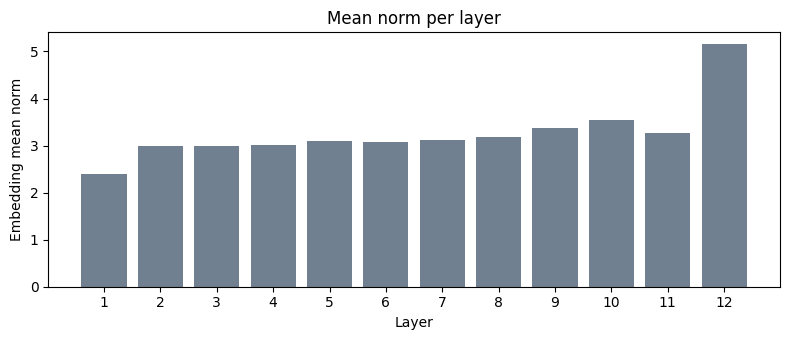

In [ ]:
layer_norms = np.linalg.norm(X_layers, axis=2).mean(axis=0)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(1, xc.N_LAYERS + 1), layer_norms, color='slategray')
ax.set_xlabel('Layer'); ax.set_ylabel('Embedding mean norm')
ax.set_title('Mean norm per layer')
ax.set_xticks(range(1, xc.N_LAYERS + 1))
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'layer_norms_diagnostic.png', dpi=150); plt.show()

## 3 · Per-layer probing - selection on validation
The best layer is chosen on **Session 4** (internal validation); the test
set is used only once, to report the metrics of the already-chosen layer.

In [ ]:
from sklearn.metrics import recall_score

layer_val_acc, layer_val_ua = [], []
for l in range(xc.N_LAYERS):
    sc = StandardScaler().fit(X_lay_tr[~inner_val][:, l, :])
    clf = LogisticRegression(max_iter=2000).fit(sc.transform(X_lay_tr[~inner_val][:, l, :]),
                                               y_tr[~inner_val])
    pred_v = clf.predict(sc.transform(X_lay_tr[inner_val][:, l, :]))
    acc = float((pred_v == y_tr[inner_val]).mean())
    ua = float(recall_score(y_tr[inner_val], pred_v, average='macro'))
    layer_val_acc.append(acc); layer_val_ua.append(ua)
    print(f'  Layer {l+1:2d}: val acc = {acc:.3f}   UA = {ua:.3f}')
# selection based on UA: with imbalanced classes, WA favors the frequent classes;
# UA (macro recall) is the standard SER metric used throughout the project
BEST_LAYER = int(np.argmax(layer_val_ua))

# single evaluation on the test set: the layer has already been chosen
sc_best = StandardScaler().fit(X_lay_tr[:, BEST_LAYER, :])
clf_best = LogisticRegression(max_iter=2000).fit(sc_best.transform(X_lay_tr[:, BEST_LAYER, :]), y_tr)
best_layer_test = xc.metrics_report(y_te, clf_best.predict(sc_best.transform(X_lay_te[:, BEST_LAYER, :])))
print(f'\nBest layer (based on validation): {BEST_LAYER + 1} -> test: {best_layer_test}')

  Layer  1: val acc = 0.574   UA = 0.551
  Layer  2: val acc = 0.540   UA = 0.512
  Layer  3: val acc = 0.579   UA = 0.558
  Layer  4: val acc = 0.540   UA = 0.521
  Layer  5: val acc = 0.548   UA = 0.529
  Layer  6: val acc = 0.572   UA = 0.554
  Layer  7: val acc = 0.558   UA = 0.542
  Layer  8: val acc = 0.546   UA = 0.544
  Layer  9: val acc = 0.591   UA = 0.587
  Layer 10: val acc = 0.565   UA = 0.548
  Layer 11: val acc = 0.578   UA = 0.569
  Layer 12: val acc = 0.579   UA = 0.574

Best layer (based on validation): 9 -> test: {'accuracy': 0.5592, 'ua': 0.5765, 'macro_f1': 0.5596}


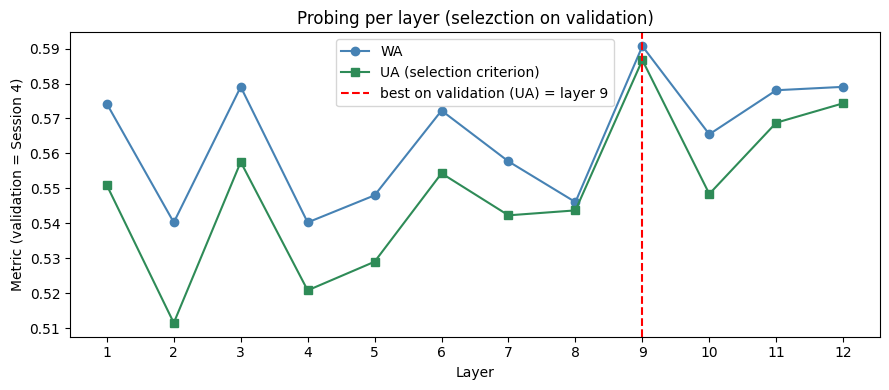

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, xc.N_LAYERS + 1), layer_val_acc, marker='o', color='steelblue', label='WA')
ax.plot(range(1, xc.N_LAYERS + 1), layer_val_ua, marker='s', color='seagreen', label='UA (selection criterion)')
ax.axvline(BEST_LAYER + 1, color='red', linestyle='--', label=f'best on validation (UA) = layer {BEST_LAYER + 1}')
ax.set_xlabel('Layer'); ax.set_ylabel('Metric (validation = Session 4)')
ax.set_title('Probing per layer (selezction on validation)')
ax.set_xticks(range(1, xc.N_LAYERS + 1)); ax.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'layer_accuracy.png', dpi=150); plt.show()

## 4 · Weighted Layer Aggregation
Shared training (`xc.train_aggregator`): minibatch 256, early
stopping on Session 4, same hyperparameters also used in NB3's LOSO.

  early stopping @ epoch 112


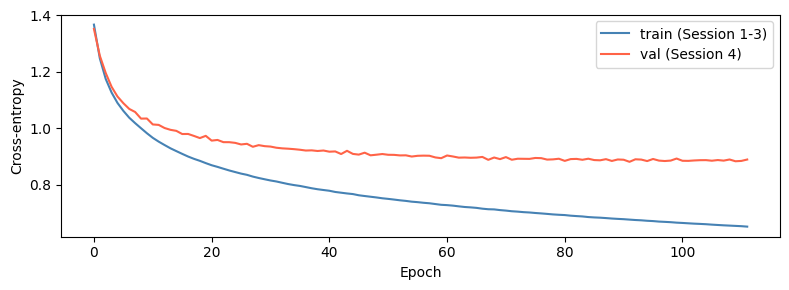

In [ ]:
aggregator, hist = xc.train_aggregator(X_lay_tr, y_tr, inner_val, device=DEVICE, verbose=True)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(hist['train'], color='steelblue', label='train (Session 1-3)')
ax.plot(hist['val'], color='tomato', label='val (Session 4)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy'); ax.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'training_loss.png', dpi=150); plt.show()

Weighted aggregation: {'accuracy': 0.6374, 'ua': 0.6487, 'macro_f1': 0.6389}
r(alpha, probe-val-acc) = +0.255 


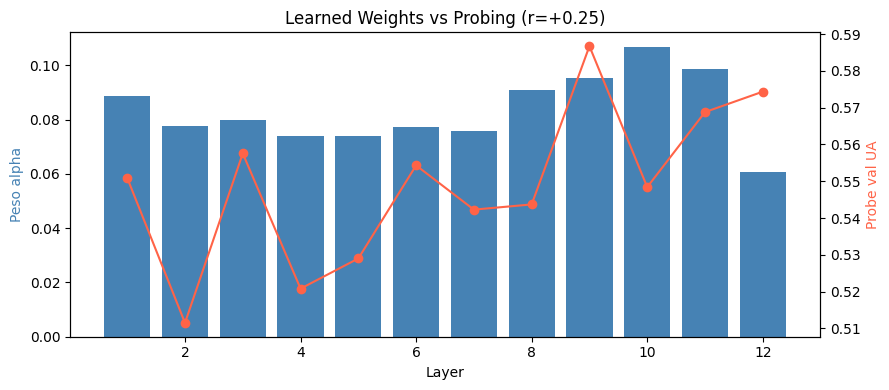

In [ ]:
with torch.no_grad():
    y_pred_wa = aggregator(torch.tensor(X_lay_te, dtype=torch.float32).to(DEVICE)).cpu().argmax(1).numpy()
wa_metrics = xc.metrics_report(y_te, y_pred_wa)
print('Weighted aggregation:', wa_metrics)

alpha = torch.softmax(aggregator.layer_weights, 0).detach().cpu().numpy()
r_alpha = float(np.corrcoef(alpha, layer_val_ua)[0, 1])
print(f'r(alpha, probe-val-acc) = {r_alpha:+.3f} ')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, xc.N_LAYERS + 1), alpha, color='steelblue')
ax2 = ax.twinx()
ax2.plot(range(1, xc.N_LAYERS + 1), layer_val_ua, color='tomato', marker='o', label='probe val UA')
ax.set_xlabel('Layer'); ax.set_ylabel('Peso alpha', color='steelblue')
ax2.set_ylabel('Probe val UA', color='tomato')
ax.set_title(f'Learned Weights vs Probing (r={r_alpha:+.2f})')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'layer_weights.png', dpi=150); plt.show()

torch.save(aggregator.state_dict(), MODEL_DIR / 'aggregator.pt')

## 5 · Weighted Rappresentation


In [ ]:
# Compute the alpha-weighted representation (768-d) from the 12 per-layer
# embeddings, using the frozen aggregator trained above - no gradient here,
# this is inference only, not further training.
def get_weighted_repr(X_lay):
    with torch.no_grad():
        return aggregator.aggregate(torch.tensor(X_lay, dtype=torch.float32).to(DEVICE)).cpu().numpy()

X_emb_tr, X_emb_te = get_weighted_repr(X_lay_tr), get_weighted_repr(X_lay_te)
scaler_emb = StandardScaler().fit(X_emb_tr)
X_emb_tr_sc, X_emb_te_sc = scaler_emb.transform(X_emb_tr), scaler_emb.transform(X_emb_te)
joblib.dump(scaler_emb, MODEL_DIR / 'scaler_emb.pkl')
print(f'Train: {X_emb_tr_sc.shape}   Test: {X_emb_te_sc.shape}')

Train: (4290, 768)   Test: (1241, 768)


## 6 · Concepts binarization
Thresholds = **per-gender** median estimated on **train only**: removes the
pitch/gender confound without using per-speaker test statistics
(deployment-valid: for a new utterance, the speaker's gender is enough). The
thresholds are saved and reusable (test, LOSO, deployment).

In [ ]:
C_bin, thresholds = xc.binarize_concepts(X_concepts, concept_names, genders, train_mask)
xc.atomic_json(MODEL_DIR / 'binarization_thresholds.json', thresholds)
C_bin_tr, C_bin_te = C_bin[train_mask], C_bin[test_mask]

print('Balance of concepts (train / test, fraction of 1):')
for k, name in enumerate(concept_names):
    print(f'  {name:12s}  {C_bin_tr[:, k].mean():.2f} / {C_bin_te[:, k].mean():.2f}')

Balance of concepts (train / test, fraction of 1):
  pitch_mean    0.50 / 0.50
  pitch_std     0.50 / 0.59
  pitch_range   0.50 / 0.54
  pitch_slope   0.50 / 0.51
  voiced_ratio  0.50 / 0.58
  rms_mean      0.50 / 0.42
  rms_cv        0.50 / 0.48
  rms_slope     0.50 / 0.52
  speech_rate   0.50 / 0.49
  pause_ratio   0.44 / 0.41
  pause_dur_mean  0.37 / 0.32
  jitter        0.50 / 0.52
  shimmer       0.50 / 0.49
  hnr           0.50 / 0.63
  alpha_ratio   0.50 / 0.73
  mfcc_1        0.50 / 0.40
  mfcc_2        0.50 / 0.56
  mfcc_3        0.50 / 0.58
  mfcc_4        0.50 / 0.52
  valence       0.53 / 0.56
  activation    0.63 / 0.66
  dominance     0.67 / 0.63


## 7 · Concept probes (weighted representation vs pure best layer)
 Fit one linear probe per concept on the alpha-weighted embedding (predicts the binarized concept from X_emb_tr_sc), and, as a comparison, one probe per concept on the single best pure layer (BEST_LAYER, chosen earlier via validation) with its own separate scaler. This checks whether the weighted aggregation actually buys anything at the concept level, not just for the final emotion label - a different, complementary check to the alpha/probing correlation done above (that one was about task accuracy, this one is about concept readability).

In [ ]:
probes = xc.fit_probes(X_emb_tr_sc, C_bin_tr, concept_names, inner_val=inner_val)
probe_metrics = {c: xc.metrics_report(C_bin_te[:, k], probes[c].predict(X_emb_te_sc))
                 for k, c in enumerate(concept_names)}

sc_pure = StandardScaler().fit(X_lay_tr[:, BEST_LAYER, :])
probes_pure = xc.fit_probes(sc_pure.transform(X_lay_tr[:, BEST_LAYER, :]), C_bin_tr, concept_names,
                            inner_val=inner_val)
probe_metrics_pure = {c: xc.metrics_report(C_bin_te[:, k],
                        probes_pure[c].predict(sc_pure.transform(X_lay_te[:, BEST_LAYER, :])))
                      for k, c in enumerate(concept_names)}

print(f'{"concept":13s} {"weighted acc/UA":>15s} {"pure layer acc":>15s}')
for c in concept_names:
    print(f'{c:13s}   {probe_metrics[c]["accuracy"]:.3f}/{probe_metrics[c]["ua"]:.3f}'
          f'          {probe_metrics_pure[c]["accuracy"]:.3f}')
xc.atomic_json(RESULTS_DIR / 'probe_accuracy.json',
               {'weighted': probe_metrics, 'pure_best_layer': probe_metrics_pure})
joblib.dump(probes, MODEL_DIR / 'probes.pkl')

concept       weighted acc/UA  pure layer acc
pitch_mean      0.867/0.867          0.821
pitch_std       0.717/0.715          0.685
pitch_range     0.734/0.734          0.681
pitch_slope     0.655/0.655          0.662
voiced_ratio    0.705/0.699          0.657
rms_mean        0.804/0.811          0.798
rms_cv          0.899/0.899          0.833
rms_slope       0.782/0.783          0.765
speech_rate     0.767/0.769          0.736
pause_ratio     0.836/0.837          0.790
pause_dur_mean   0.853/0.842          0.826
jitter          0.738/0.737          0.699
shimmer         0.716/0.715          0.680
hnr             0.855/0.852          0.796
alpha_ratio     0.828/0.838          0.721
mfcc_1          0.812/0.821          0.795
mfcc_2          0.867/0.866          0.804
mfcc_3          0.881/0.883          0.832
mfcc_4          0.798/0.800          0.716
valence         0.730/0.717          0.696
activation      0.745/0.728          0.742
dominance       0.636/0.604          0.613


['/content/drive/MyDrive/Colab Notebooks/XAI_SER/code/my_outputs_Hubert/my_model/probes.pkl']

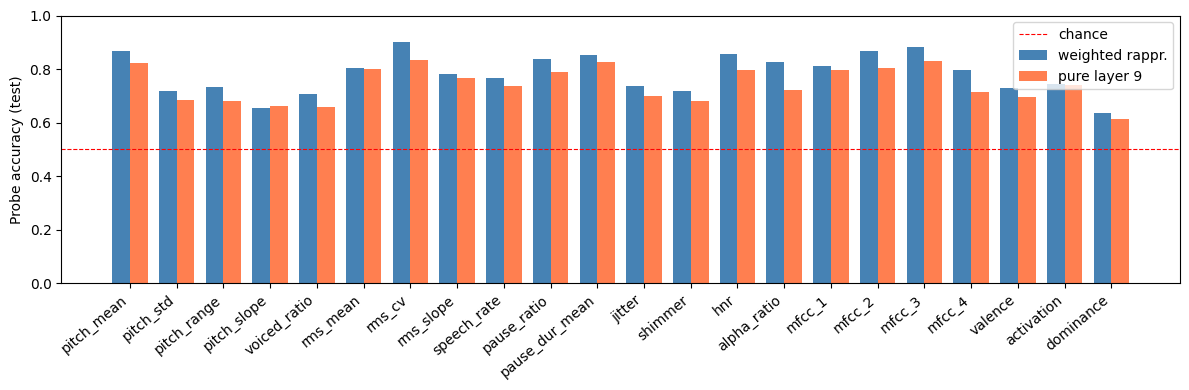

In [ ]:
x = np.arange(len(concept_names)); w = 0.38
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, [probe_metrics[c]['accuracy'] for c in concept_names], w,
       color='steelblue', label='weighted rappr.')
ax.bar(x + w/2, [probe_metrics_pure[c]['accuracy'] for c in concept_names], w,
       color='coral', label=f'pure layer {BEST_LAYER + 1}')
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='chance')
ax.set_xticks(x); ax.set_xticklabels(concept_names, rotation=40, ha='right')
ax.set_ylabel('Probe accuracy (test)'); ax.set_ylim(0, 1); ax.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'probe_accuracy.png', dpi=150); plt.show()

## 8 · CBM on three concept levels + hard variant

- `acoustic` - main, deployable set: the only one used in the XAI evaluation (NB3);
- `acoustic+mfcc` - ablation: how much non-interpretable features add;
- `acoustic+dim` -  To be read as an upper bound, not as a deployable CBM.

The **hard** variant (0/1 concepts) mitigates soft leakage: probe
probabilities can carry information about the label beyond the concept's
own content (Mahinpei et al. 2021), all the more so since the aggregated
embedding is itself supervised by the emotion label.

In [ ]:
CONFIGS = {'acoustic':      xc.ACOUSTIC_CONCEPTS,
           'acoustic+mfcc': xc.ACOUSTIC_CONCEPTS + xc.MFCC_CONCEPTS,
           'acoustic+dim':  xc.ACOUSTIC_CONCEPTS + xc.DIM_CONCEPTS}

cbm_models, cbm_metrics = {}, {}
for cfg, subset in CONFIGS.items():
    C_tr = xc.concept_scores(probes, X_emb_tr_sc, subset)
    C_te = xc.concept_scores(probes, X_emb_te_sc, subset)
    pipe = xc.fit_cbm_head(C_tr, y_tr, inner_val=inner_val)   # C chosen on layer 4
    cbm_models[cfg] = pipe
    cbm_metrics[cfg] = xc.metrics_report(y_te, pipe.predict(C_te))
    warn = '  <-- upper bound with quasi-label!' if cfg == 'acoustic+dim' else ''
    print(f'CBM [{cfg:14s}] K={len(subset):2d} C={pipe.best_C:<5} {cbm_metrics[cfg]}{warn}')

# HARD variant on acoustic set
C_tr_h = xc.concept_scores(probes, X_emb_tr_sc, xc.ACOUSTIC_CONCEPTS, hard=True)
C_te_h = xc.concept_scores(probes, X_emb_te_sc, xc.ACOUSTIC_CONCEPTS, hard=True)
cbm_hard = xc.fit_cbm_head(C_tr_h, y_tr, inner_val=inner_val)
cbm_hard_metrics = xc.metrics_report(y_te, cbm_hard.predict(C_te_h))
print(f'CBM [acoustic HARD ]       {cbm_hard_metrics}')

d_mfcc = cbm_metrics['acoustic+mfcc']['accuracy'] - cbm_metrics['acoustic']['accuracy']
print(f'\nDelta accuracy of MFCC probe: {d_mfcc:+.3f}')

cbm = cbm_models['acoustic']
C_tr_ac = xc.concept_scores(probes, X_emb_tr_sc, xc.ACOUSTIC_CONCEPTS)
C_te_ac = xc.concept_scores(probes, X_emb_te_sc, xc.ACOUSTIC_CONCEPTS)
y_pred_cbm = cbm.predict(C_te_ac)
print(); print(classification_report(y_te, y_pred_cbm, target_names=xc.LABEL_NAMES))
joblib.dump(cbm_models, MODEL_DIR / 'cbm_configs.pkl')
joblib.dump(cbm_hard, MODEL_DIR / 'cbm_hard.pkl')

CBM [acoustic      ] K=15 C=0.1   {'accuracy': 0.4666, 'ua': 0.5255, 'macro_f1': 0.4657}
CBM [acoustic+mfcc ] K=19 C=0.1   {'accuracy': 0.4762, 'ua': 0.5358, 'macro_f1': 0.4742}
CBM [acoustic+dim  ] K=18 C=1.0   {'accuracy': 0.6019, 'ua': 0.6197, 'macro_f1': 0.611}  <-- upper bound with quasi-label!
CBM [acoustic HARD ]       {'accuracy': 0.4384, 'ua': 0.5068, 'macro_f1': 0.4382}

Delta accuracy of MFCC probe: +0.010

              precision    recall  f1-score   support

     neutral       0.51      0.47      0.49       384
       happy       0.58      0.25      0.35       442
         sad       0.48      0.72      0.58       245
       angry       0.34      0.66      0.45       170

    accuracy                           0.47      1241
   macro avg       0.48      0.53      0.47      1241
weighted avg       0.51      0.47      0.45      1241



['/content/drive/MyDrive/Colab Notebooks/XAI_SER/code/my_outputs_Hubert/my_model/cbm_hard.pkl']

## 9 · Black-box baseline + significance
Same weighted representation (isolates the bottleneck effect) + a stronger
black-box on the 12 concatenated layers.

In [ ]:
baseline = xc.fit_logreg(X_emb_tr_sc, y_tr, inner_val=inner_val, class_weight='balanced')
y_pred_base = baseline.predict(X_emb_te_sc)
base_metrics = xc.metrics_report(y_te, y_pred_base)

# MLP black-box with the SAME training/validation protocol as the other
# models (early stopping on Session 4, speaker-independent): sklearn's
# MLPClassifier used an internal random split, not comparable

mlp_net, hist_m = xc.train_mlp(X_emb_tr_sc.astype(np.float32), y_tr, inner_val, device=DEVICE)
mlp = xc.TorchClf(mlp_net)
y_pred_mlp = mlp.predict(X_emb_te_sc)
mlp_metrics = xc.metrics_report(y_te, y_pred_mlp)

# stronger black-box: 12 concatenated layers (12 x 768 = 9216 features)
X_cat_tr = X_lay_tr.reshape(len(X_lay_tr), -1)
X_cat_te = X_lay_te.reshape(len(X_lay_te), -1)
sc_cat = StandardScaler().fit(X_cat_tr)
mlp_cat_net, _ = xc.train_mlp(sc_cat.transform(X_cat_tr).astype(np.float32), y_tr,
                              inner_val, device=DEVICE)
mlp_cat = xc.TorchClf(mlp_cat_net)
y_pred_cat = mlp_cat.predict(sc_cat.transform(X_cat_te))
mlp_cat_metrics = xc.metrics_report(y_te, y_pred_cat)

joblib.dump(baseline, MODEL_DIR / 'baseline.pkl')
joblib.dump(mlp, MODEL_DIR / 'mlp.pkl')

print(f'CBM acoustic      : {cbm_metrics["acoustic"]}')
print(f'Baseline lineare  : {base_metrics}')
print(f'MLP (emb weighted)  : {mlp_metrics}')
print(f'MLP (12 layer)    : {mlp_cat_metrics}')

print('\nMcNemar CBM vs MLP      :', xc.mcnemar(y_te, y_pred_cbm, y_pred_mlp))
print('Bootstrap CI (acc diff) :', xc.bootstrap_diff_ci(y_te, y_pred_cbm, y_pred_mlp))

CBM acoustic      : {'accuracy': 0.4666, 'ua': 0.5255, 'macro_f1': 0.4657}
Baseline lineare  : {'accuracy': 0.6704, 'ua': 0.6774, 'macro_f1': 0.6737}
MLP (emb pesato)  : {'accuracy': 0.6559, 'ua': 0.6638, 'macro_f1': 0.6558}
MLP (12 layer)    : {'accuracy': 0.6446, 'ua': 0.6526, 'macro_f1': 0.6451}

McNemar CBM vs MLP      : {'n_only_a': 121, 'n_only_b': 356, 'p_value': 6.776553574935101e-28}
Bootstrap CI (acc diff) : {'diff_mean': -0.1893, 'ci95': [-0.2216, -0.1563]}


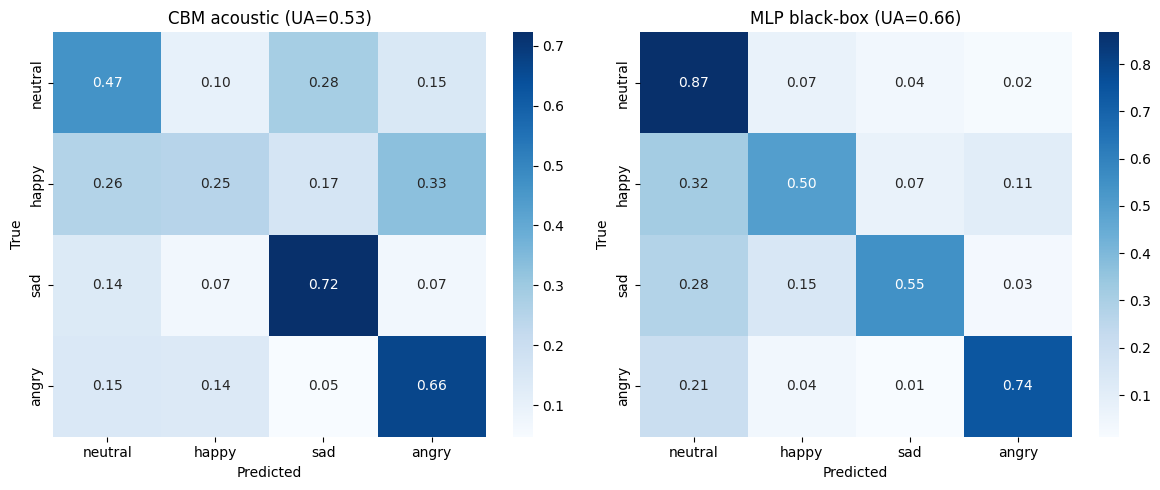

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (y_pred, title) in zip(axes, [
        (y_pred_cbm, f'CBM acoustic (UA={cbm_metrics["acoustic"]["ua"]:.2f})'),
        (y_pred_mlp, f'MLP black-box (UA={mlp_metrics["ua"]:.2f})')]):
    cm = confusion_matrix(y_te, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', ax=ax, cmap='Blues',
                xticklabels=xc.LABEL_NAMES, yticklabels=xc.LABEL_NAMES)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'confusion_matrices.png', dpi=150); plt.show()

## 10 · Intervention curves
Acoustic set only: concepts a human can actually act on (intervening on
"mfcc_3" doesn't make practical sense). Two policies:
- **random** - shared random order (10 trials, as in Koh et al. 2020);
- **uncertainty** - for each sample, the concepts with the most uncertain
  probe (minimum |p−0.5|) are corrected first: the realistic policy of an
  assisted annotator.

> **Methodological note.** The intervention replaces *soft* scores (probe
> probabilities) with 0/1 ground-truth values inside a pipeline whose scaler
> was fitted on the soft scores: this is standard practice for sequential
> CBMs (Koh et al. 2020), but it introduces a distributional shift that
> should be disclosed. With low oracle completeness (CBM on GT concepts ≈
> CBM on predicted concepts), the headroom for interventions is structurally
> limited: a flat curve should be read as a **limit of the concept set's
> completeness**, not as evidence of controllability.

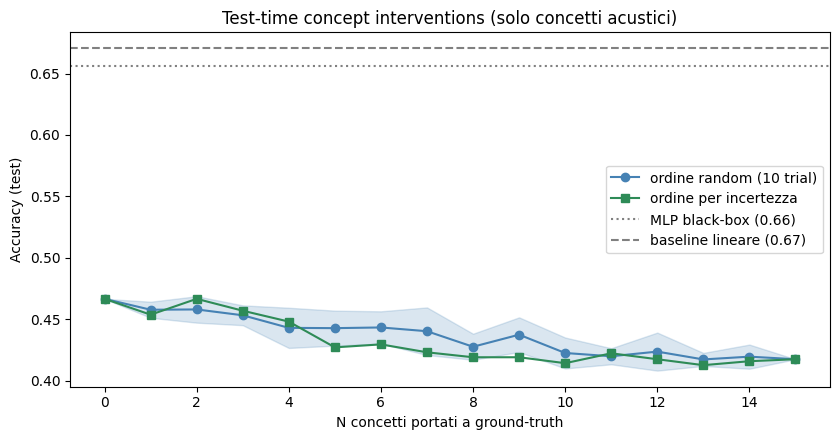

Random:      0.467 -> 0.417
Uncertainty: 0.467 -> 0.417


In [ ]:
a_idx = [concept_names.index(c) for c in xc.ACOUSTIC_CONCEPTS]
C_gt_te = C_bin_te[:, a_idx].astype(np.float32)
K = len(xc.ACOUSTIC_CONCEPTS)
rng = np.random.default_rng(xc.SEED)

def apply_intervention(C_pred, C_gt, order_idx, n_int):
    # order_idx: (N, K) per-sample order of the concepts to correct
    # For each row, replace the first n_int concepts (in that row's own order)
    # with their ground-truth value; the rest keep the model's predicted score.
    C_int = C_pred.copy()
    if n_int > 0:
        rows = np.arange(len(C_pred))[:, None]
        cols = order_idx[:, :n_int]
        C_int[rows, cols] = C_gt[rows, cols]
    return C_int
# Policy 1: random order, shared across the whole batch but re-shuffled per
# trial (10 trials) -> mean +/- std curve, as in Koh et al. 2020.
N_TRIALS = 10
rand_mean, rand_std = [], []
for n_int in range(K + 1):
    accs = []
    for _ in range(N_TRIALS):
        order = np.tile(rng.permutation(K), (len(C_te_ac), 1))
        accs.append(float((cbm.predict(apply_intervention(C_te_ac, C_gt_te, order, n_int)) == y_te).mean()))
    rand_mean.append(np.mean(accs)); rand_std.append(np.std(accs))
rand_mean, rand_std = np.array(rand_mean), np.array(rand_std)
# Policy 2: uncertainty order, per-sample (not shared): correct first the
# concepts whose probe is closest to the decision boundary (|p-0.5| minimum) -
# the realistic policy of an assisted annotator who fixes the least confident
# predictions first. Deterministic, no need for multiple trials.
unc_order = np.argsort(np.abs(C_te_ac - 0.5), axis=1)     #firstly the most uncertain
unc_curve = np.array([float((cbm.predict(apply_intervention(C_te_ac, C_gt_te, unc_order, n)) == y_te).mean())
                      for n in range(K + 1)])

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(range(K + 1), rand_mean, marker='o', color='steelblue', label='Random order (10 trials)')
ax.fill_between(range(K + 1), rand_mean - rand_std, rand_mean + rand_std, alpha=0.2, color='steelblue')
ax.plot(range(K + 1), unc_curve, marker='s', color='seagreen', label='Uncertainty-based order')
ax.axhline(mlp_metrics['accuracy'], color='gray', linestyle=':', label=f"Black-box MLP ({mlp_metrics['accuracy']:.2f})")
ax.axhline(base_metrics['accuracy'], color='gray', linestyle='--', label=f"Linear baseline ({base_metrics['accuracy']:.2f})")
ax.set_xlabel('Number of concepts set to ground truth'); ax.set_ylabel('Accuracy (test)')
ax.set_title('Test-time concept interventions (Only acoustic concepts)')
ax.legend(); plt.tight_layout(); plt.savefig(RESULTS_DIR / 'intervention_curve.png', dpi=150); plt.show()
print(f'Random:      {rand_mean[0]:.3f} -> {rand_mean[-1]:.3f}')
print(f'Uncertainty: {unc_curve[0]:.3f} -> {unc_curve[-1]:.3f}')

## 11 · Completeness of the concept set
CBM on ground-truth concepts: upper bound of the emotional information
contained in the 9 acoustic concepts, independent of probe quality.

In [ ]:
oracle = xc.fit_cbm_head(C_bin_tr[:, a_idx].astype(np.float32), y_tr, inner_val=inner_val)
oracle_metrics = xc.metrics_report(y_te, oracle.predict(C_gt_te))
print(f'Oracle (Acoustic GT) : {oracle_metrics}')
print(f'CBM (predicted)       : {cbm_metrics["acoustic"]}')
print(f'MLP black-box        : {mlp_metrics}')

Oracle (Acoustic GT) : {'accuracy': 0.4214, 'ua': 0.4787, 'macro_f1': 0.4226}
CBM (predicted)       : {'accuracy': 0.4666, 'ua': 0.5255, 'macro_f1': 0.4657}
MLP black-box        : {'accuracy': 0.6559, 'ua': 0.6638, 'macro_f1': 0.6558}


## 11bis · Targeted interventions (wrong probes only) + hard vs oracle significance
The average curve intervenes even where the probes are already correct. Here
we correct only the wrong concepts: if accuracy still doesn't improve even
so, the limit is the concept vocabulary itself, not how well it's predicted.
At the end: McNemar and bootstrap CI on hard vs oracle.

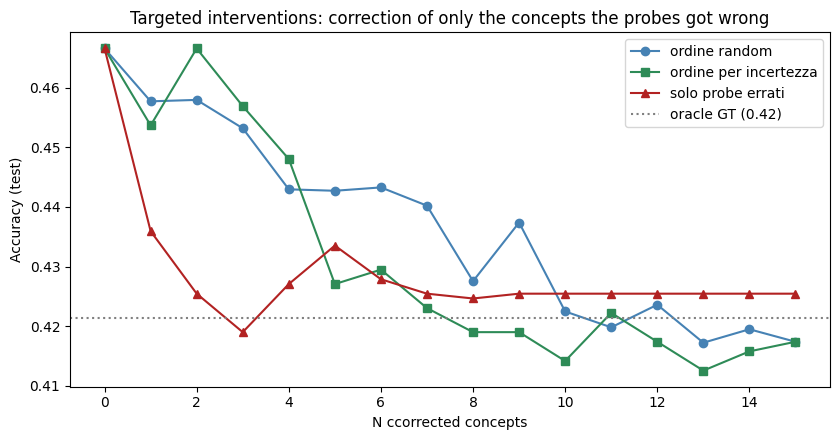

Targeted: 0.467 -> 0.425
Subgroup (>=1 error, n=1201, err medi 3.35): 0.460 -> 0.418
McNemar hard vs oracle: {'n_only_a': 191, 'n_only_b': 170, 'p_value': 0.29249822705679873}
Bootstrap 95% CI (hard - oracle): {'diff_mean': 0.0165, 'ci95': [-0.0137, 0.0451]}


In [ ]:
E_probe = (C_te_ac > 0.5).astype(np.float32) != C_gt_te
n_err = E_probe.sum(axis=1).astype(int)
targ_order = np.argsort(~E_probe, axis=1, kind='stable')   # firstly wrong concepts

def targeted_intervention(C_pred, C_gt, n_int):
    C_int = C_pred.copy()
    if n_int > 0:
        rows = np.arange(len(C_pred))[:, None]
        cols = targ_order[:, :n_int]
        fix = np.take_along_axis(E_probe, cols, axis=1)    # it doesn't touch correct concepts
        C_int[rows, cols] = np.where(fix, C_gt[rows, cols], C_int[rows, cols])
    return C_int

targ_curve = np.array([float((cbm.predict(targeted_intervention(C_te_ac, C_gt_te, n)) == y_te).mean())
                       for n in range(K + 1)])

sub = n_err > 0
pred_base = cbm.predict(C_te_ac)
pred_full = cbm.predict(targeted_intervention(C_te_ac, C_gt_te, K))
targ_subgroup = {'n_samples': int(sub.sum()),
                 'err_mean': round(float(n_err[sub].mean()), 3),
                 'acc_before': round(float((pred_base[sub] == y_te[sub]).mean()), 4),
                 'acc_after': round(float((pred_full[sub] == y_te[sub]).mean()), 4)}

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(range(K + 1), rand_mean, marker='o', color='steelblue', label='ordine random')
ax.plot(range(K + 1), unc_curve, marker='s', color='seagreen', label='ordine per incertezza')
ax.plot(range(K + 1), targ_curve, marker='^', color='firebrick', label='solo probe errati')
ax.axhline(oracle_metrics['accuracy'], color='gray', linestyle=':',
           label=f"oracle GT ({oracle_metrics['accuracy']:.2f})")
ax.set_xlabel('N ccorrected concepts'); ax.set_ylabel('Accuracy (test)')
ax.set_title('Targeted interventions: correction of only the concepts the probes got wrong')
ax.legend(); plt.tight_layout(); plt.savefig(RESULTS_DIR / 'intervention_targeted.png', dpi=150); plt.show()
print(f'Targeted: {targ_curve[0]:.3f} -> {targ_curve[-1]:.3f}')
print(f"Subgroup (>=1 error, n={targ_subgroup['n_samples']}, err medi {targ_subgroup['err_mean']}): "
      f"{targ_subgroup['acc_before']:.3f} -> {targ_subgroup['acc_after']:.3f}")

y_pred_hard = cbm_hard.predict(C_te_h)
y_pred_oracle = oracle.predict(C_gt_te)
mcnemar_hard_oracle = xc.mcnemar(y_te, y_pred_hard, y_pred_oracle)
boot_hard_oracle = xc.bootstrap_diff_ci(y_te, y_pred_hard, y_pred_oracle)
print(f'McNemar hard vs oracle: {mcnemar_hard_oracle}')
print(f'Bootstrap 95% CI (hard - oracle): {boot_hard_oracle}')

## Continuous CBM (ablation): the cost of binarization
Concepts standardized per gender (z-score with train-only statistics - the
continuous analogue of the per-gender medians, equally deployment-valid),
**Ridge regression** probes instead of logistic ones, same head. The median
split throws away the concept's intensity information: this variant
quantifies how much that costs. Interventions: the predicted score is
replaced by the standardized GT value (random order), as in the binary
variant.

In [ ]:
Xz, z_params = xc.standardize_concepts(X_concepts, concept_names, genders, train_mask)
xc.atomic_json(MODEL_DIR / 'standardization_params.json', z_params)
Cz_tr = Xz[train_mask][:, a_idx].astype(np.float32)
Cz_te = Xz[test_mask][:, a_idx].astype(np.float32)

reg_probes = xc.fit_reg_probes(X_emb_tr_sc, Cz_tr, xc.ACOUSTIC_CONCEPTS, inner_val=inner_val)
Rz_tr = xc.reg_concept_scores(reg_probes, X_emb_tr_sc, xc.ACOUSTIC_CONCEPTS)
Rz_te = xc.reg_concept_scores(reg_probes, X_emb_te_sc, xc.ACOUSTIC_CONCEPTS)

from sklearn.metrics import r2_score
probe_r2 = {c: round(float(r2_score(Cz_te[:, k], Rz_te[:, k])), 4)
            for k, c in enumerate(xc.ACOUSTIC_CONCEPTS)}
print('R2 of the regression probes (test):')
print('  ' + '  '.join(f'{c}={v:.2f}' for c, v in probe_r2.items()))

cbm_cont = xc.fit_cbm_head(Rz_tr, y_tr, inner_val=inner_val)
cbm_cont_metrics = xc.metrics_report(y_te, cbm_cont.predict(Rz_te))
oracle_cont = xc.fit_cbm_head(Cz_tr, y_tr, inner_val=inner_val)
oracle_cont_metrics = xc.metrics_report(y_te, oracle_cont.predict(Cz_te))
print(f'Continuous CBM : {cbm_cont_metrics}')
print(f'  (binary      : {cbm_metrics["acoustic"]})')
print(f'Continuous oracle : {oracle_cont_metrics}')
print(f'  (binary      : {oracle_metrics})')

rng_c = np.random.default_rng(xc.SEED)
cont_curve = []
for n_int in range(K + 1):
    accs = []
    for _ in range(N_TRIALS):
        order = np.tile(rng_c.permutation(K), (len(Rz_te), 1))
        accs.append(float((cbm_cont.predict(apply_intervention(Rz_te, Cz_te, order, n_int)) == y_te).mean()))
    cont_curve.append(float(np.mean(accs)))
print(f'Interventions (continuous, random order): {cont_curve[0]:.3f} -> {cont_curve[-1]:.3f}')
joblib.dump({'reg_probes': reg_probes, 'cbm_cont': cbm_cont}, MODEL_DIR / 'cbm_continuous.pkl')

R2 of the regression probes (test):
  pitch_mean=0.67  pitch_std=0.29  pitch_range=0.31  pitch_slope=0.10  voiced_ratio=0.27  rms_mean=0.30  rms_cv=0.89  rms_slope=0.52  speech_rate=0.53  pause_ratio=0.57  pause_dur_mean=0.49  jitter=0.45  shimmer=0.40  hnr=0.80  alpha_ratio=0.73
Continuous CBM : {'accuracy': 0.4843, 'ua': 0.5321, 'macro_f1': 0.4854}
  (binary      : {'accuracy': 0.4666, 'ua': 0.5255, 'macro_f1': 0.4657})
Continuous oracle : {'accuracy': 0.4698, 'ua': 0.5005, 'macro_f1': 0.4747}
  (binary      : {'accuracy': 0.4214, 'ua': 0.4787, 'macro_f1': 0.4226})
Interventions (continuous, random order): 0.484 -> 0.464


['/content/drive/MyDrive/Colab Notebooks/XAI_SER/code/my_outputs_Hubert/my_model/cbm_continuous.pkl']

## 12 · Single Intervention

In [ ]:
neu_idx = np.where(y_te == 0)[0]
cols = [xc.ACOUSTIC_CONCEPTS.index(c) for c in ['pitch_mean', 'rms_mean', 'speech_rate']]

C_orig = C_te_ac[neu_idx].copy()
pred_orig = cbm.predict(C_orig)
C_int = C_orig.copy(); C_int[:, cols] = 1.0
pred_int = cbm.predict(C_int)

changed = float((pred_orig != pred_int).mean())
print(f'Neutral with high pitch+energy+speech_rate: {changed:.2f} change class')
print('Nuova distribuzione:', dict(Counter(xc.LABEL_NAMES[p] for p in pred_int)))

Neutral with high pitch+energy+speech_rate: 0.58 change class
Nuova distribuzione: {'neutral': 135, 'angry': 146, 'happy': 103}


## 13 · Concept → emotion correlations (domain alignment, acoustic set)

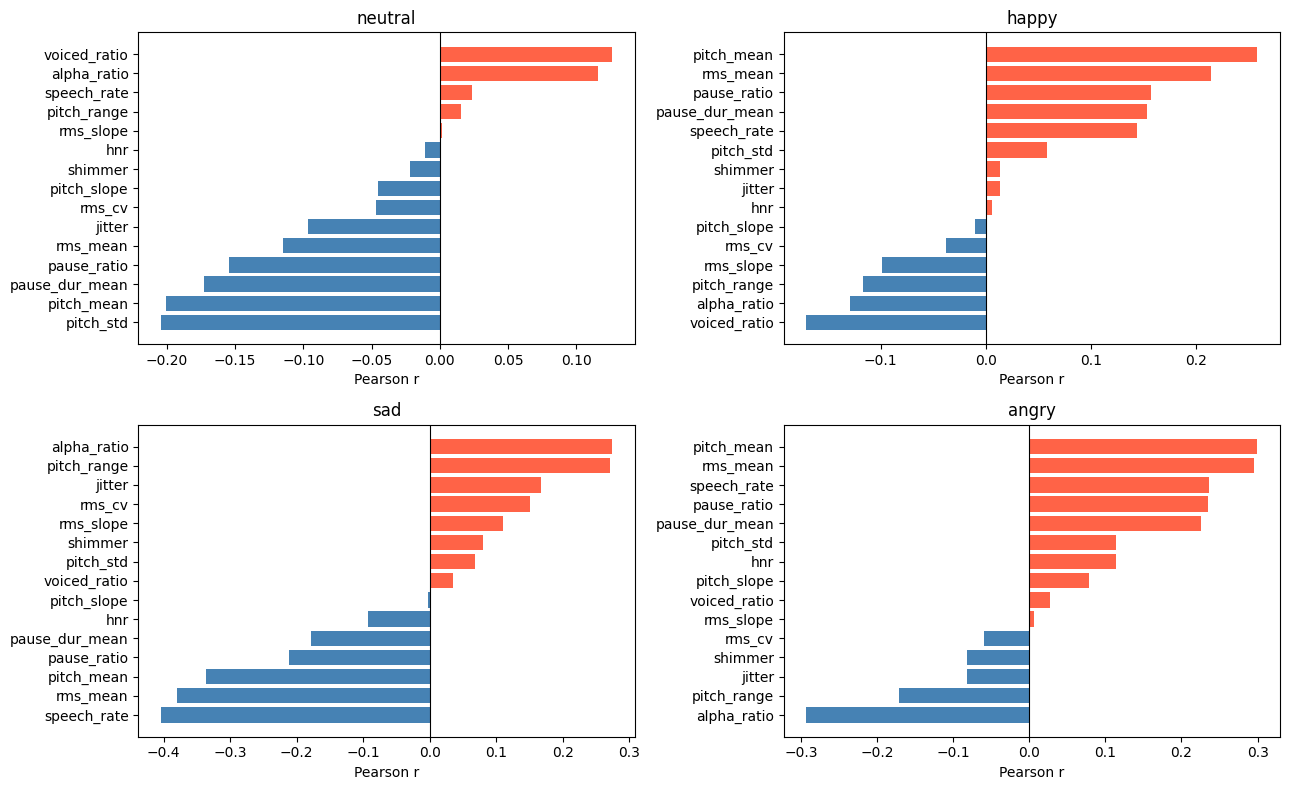

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
domain_corr = {}
for ax, (emo_id, emo_name) in zip(axes.flat, enumerate(xc.LABEL_NAMES)):
    y_bin = (y_te == emo_id).astype(float)
    corrs = {c: float(np.corrcoef(C_te_ac[:, k], y_bin)[0, 1])
             for k, c in enumerate(xc.ACOUSTIC_CONCEPTS)}
    domain_corr[emo_name] = corrs
    corrs_s = dict(sorted(corrs.items(), key=lambda x: x[1]))
    colors = ['tomato' if v > 0 else 'steelblue' for v in corrs_s.values()]
    ax.barh(list(corrs_s.keys()), list(corrs_s.values()), color=colors)
    ax.axvline(0, color='black', linewidth=0.8); ax.set_title(emo_name); ax.set_xlabel('Pearson r')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'concept_correlations.png', dpi=150); plt.show()

## 14 · Temporal breakdown - attention pooling over chunks
The brief calls for explanations anchored to the **temporal** structure of
the signal: mean pooling destroys it. This model learns attention weights
over 8 temporal segments: the explanation is WHEN the model looks, not just
what at.

Temporal attention: {'accuracy': 0.5786, 'ua': 0.6016, 'macro_f1': 0.5794}


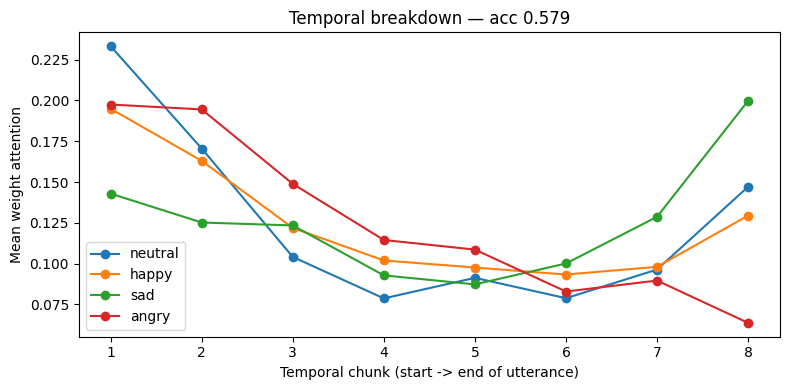

In [ ]:
temporal, hist_t = xc.train_temporal(X_chunks[train_mask], y_tr, inner_val, device=DEVICE)

X_chk_te = torch.tensor(X_chunks[test_mask], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    y_pred_temp = temporal(X_chk_te).cpu().argmax(1).numpy()
    att_te = temporal.attention(X_chk_te).cpu().numpy()
temp_metrics = xc.metrics_report(y_te, y_pred_temp)
print('Temporal attention:', temp_metrics)

fig, ax = plt.subplots(figsize=(8, 4))
for emo_id, emo in enumerate(xc.LABEL_NAMES):
    ax.plot(range(1, xc.N_CHUNKS + 1), att_te[y_te == emo_id].mean(axis=0), marker='o', label=emo)
ax.set_xlabel('Temporal chunk (start -> end of utterance)')
ax.set_ylabel('Mean weight attention')
ax.set_title(f"Temporal breakdown - acc {temp_metrics['accuracy']:.3f}")
ax.legend(); plt.tight_layout(); plt.savefig(RESULTS_DIR / 'temporal_attention.png', dpi=150); plt.show()

torch.save(temporal.state_dict(), MODEL_DIR / 'temporal_attention.pt')

## 15 · CEM - Concept Embedding Model
CEM (Zarlenga et al. 2022) narrows the gap with the black-box while keeping
interventions: each concept has an active/inactive embedding, and the
classifier sees the mixing weighted by the concept score.

In [ ]:
# RandInt p_int=0.25 (Zarlenga et al. 2022): without interventions at training
# time, the CEM doesn't learn to exploit the corrections and the intervention
# curve stays flat or decreasing
cem, hist_c = xc.train_cem(X_emb_tr_sc, y_tr, C_bin_tr[:, a_idx].astype(np.float32),
                           inner_val, device=DEVICE)
X_te_t = torch.tensor(X_emb_te_sc, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    logits, p_cem, _ = cem(X_te_t)
y_pred_cem = logits.cpu().argmax(1).numpy()
cem_metrics = xc.metrics_report(y_te, y_pred_cem)
print('CEM:', cem_metrics)

# CEM concept accuracy: without this number the intervention curve isn't
# interpretable (concepts already correct vs. a model that can't be intervened on)
p_cem_np = p_cem.cpu().numpy()
cem_concept_acc = {c: float(((p_cem_np[:, k] >= 0.5) == C_gt_te[:, k]).mean())
                   for k, c in enumerate(xc.ACOUSTIC_CONCEPTS)}
print('CEM concept accuracy (test): media '
      f'{np.mean(list(cem_concept_acc.values())):.3f}  '
      + '  '.join(f'{c}={a:.2f}' for c, a in cem_concept_acc.items()))

# intervention curve on CEM (p_k := ground-truth, random order, 5 trial)
C_gt_t = torch.tensor(C_gt_te, dtype=torch.float32).to(DEVICE)
cem_curve = []
for n_int in range(K + 1):
    accs = []
    for _ in range(5):
        mask = torch.zeros(K, device=DEVICE)
        mask[rng.permutation(K)[:n_int].tolist()] = 1
        with torch.no_grad():
            lg, _, _ = cem(X_te_t, c_int=C_gt_t, int_mask=mask.expand(len(C_gt_te), K))
        accs.append(float((lg.cpu().argmax(1).numpy() == y_te).mean()))
    cem_curve.append(float(np.mean(accs)))
print(f'CEM interventions: {cem_curve[0]:.3f} -> {cem_curve[-1]:.3f}')
torch.save(cem.state_dict(), MODEL_DIR / 'cem.pt')

CEM: {'accuracy': 0.668, 'ua': 0.6764, 'macro_f1': 0.669}
CEM concept accuracy (test): media 0.757  pitch_mean=0.83  pitch_std=0.73  pitch_range=0.73  pitch_slope=0.63  voiced_ratio=0.69  rms_mean=0.81  rms_cv=0.85  rms_slope=0.73  speech_rate=0.75  pause_ratio=0.79  pause_dur_mean=0.84  jitter=0.71  shimmer=0.70  hnr=0.82  alpha_ratio=0.74
CEM interventions: 0.668 -> 0.659


## 16 ·Summary

In [ ]:
summary = {
    'layer_val_accuracy':       [round(a, 3) for a in layer_val_acc],
    'layer_val_ua':             [round(a, 3) for a in layer_val_ua],
    'best_layer':               BEST_LAYER + 1,
    'best_layer_test':          best_layer_test,
    'weighted_agg':             wa_metrics,
    'alpha':                    [round(float(a), 4) for a in alpha],
    'r_alpha_probe':            round(r_alpha, 3),
    'probe_metrics':            probe_metrics,
    'cbm':                      cbm_metrics,
    'cbm_hard':                 cbm_hard_metrics,
    'baseline_linear':          base_metrics,
    'baseline_mlp':             mlp_metrics,
    'baseline_mlp_concat':      mlp_cat_metrics,
    'oracle_completeness':      oracle_metrics,
    'cbm_continuous':           cbm_cont_metrics,
    'oracle_continuous':        oracle_cont_metrics,
    'probe_r2':                 probe_r2,
    'intervention_cont_random': [round(c, 3) for c in cont_curve],
    'intervention_random_mean': [round(float(m), 3) for m in rand_mean],
    'intervention_uncertainty': [round(float(u), 3) for u in unc_curve],
    'intervention_targeted':    [round(float(t), 3) for t in targ_curve],
    'intervention_targeted_subgroup': targ_subgroup,
    'temporal_attention':       temp_metrics,
    'cem':                      cem_metrics,
    'cem_concept_acc':          {c: round(a, 4) for c, a in cem_concept_acc.items()},
    'cem_intervention':         [round(c, 3) for c in cem_curve],
    'best_C':                   {'cbm': {cfg: m.best_C for cfg, m in cbm_models.items()},
                                 'cbm_hard': cbm_hard.best_C,
                                 'baseline_linear': baseline.best_C},
    'mcnemar_cbm_vs_mlp':       xc.mcnemar(y_te, y_pred_cbm, y_pred_mlp),
    'mcnemar_hard_vs_oracle':   mcnemar_hard_oracle,
    'bootstrap_hard_vs_oracle': boot_hard_oracle,
    'domain_correlations':      domain_corr,
}
xc.atomic_json(RESULTS_DIR / 'summary.json', summary)
# per-sample predictions: needed by NB4 for the McNemar test across backbones
xc.atomic_json(RESULTS_DIR / 'test_predictions.json',
               {'y_true': y_te.tolist(), 'cbm': y_pred_cbm.tolist(),
                'mlp': y_pred_mlp.tolist(), 'wa': y_pred_wa.tolist(),
                'temporal': y_pred_temp.tolist(),
                'cbm_hard': y_pred_hard.tolist(), 'oracle': y_pred_oracle.tolist(),
                'cem': y_pred_cem.tolist()})
print(json.dumps({k: v for k, v in summary.items()
                  if k not in ('domain_correlations', 'probe_metrics', 'alpha',
                               'layer_val_accuracy')}, indent=2))

{
  "layer_val_ua": [
    0.551,
    0.512,
    0.558,
    0.521,
    0.529,
    0.554,
    0.542,
    0.544,
    0.587,
    0.548,
    0.569,
    0.574
  ],
  "best_layer": 9,
  "best_layer_test": {
    "accuracy": 0.5592,
    "ua": 0.5765,
    "macro_f1": 0.5596
  },
  "weighted_agg": {
    "accuracy": 0.6374,
    "ua": 0.6487,
    "macro_f1": 0.6389
  },
  "r_alpha_probe": 0.255,
  "cbm": {
    "acoustic": {
      "accuracy": 0.4666,
      "ua": 0.5255,
      "macro_f1": 0.4657
    },
    "acoustic+mfcc": {
      "accuracy": 0.4762,
      "ua": 0.5358,
      "macro_f1": 0.4742
    },
    "acoustic+dim": {
      "accuracy": 0.6019,
      "ua": 0.6197,
      "macro_f1": 0.611
    }
  },
  "cbm_hard": {
    "accuracy": 0.4384,
    "ua": 0.5068,
    "macro_f1": 0.4382
  },
  "baseline_linear": {
    "accuracy": 0.6704,
    "ua": 0.6774,
    "macro_f1": 0.6737
  },
  "baseline_mlp": {
    "accuracy": 0.6559,
    "ua": 0.6638,
    "macro_f1": 0.6558
  },
  "baseline_mlp_concat": {
    "ac